<h1 style="text-align: center;">Ingénierie des données textuelles </h1>  


De nombreux modèles utilisent des données textuelles pour des tâches de prédiction. Avant d'entraîner un classifieur, il faut préparer les documents pour qu'ils puissent être traités par le modèle. Cette étape d'ingénierie de texte consiste à transformer le texte brut en une forme exploitable et à tenir compte des différentes manières dont un texte peut être produit : réseaux sociaux, actualités, rapports, etc. La forme peut être très différetes selon les sources, et le contexte nécessite souvent d'adapter le traitement. Par exemple, dans une page HTML, les balises ne sont pas forcément utiles.

Le traitement des données textuelles présente de nombreuses difficultés. Convertir un texte en minuscules peut entraîner une perte d'information ("Mr Play" désigne une personne, alors que "play" est un verbe). Supprimer la ponctuation peut retirer des éléments importants, comme le "!" qui exprime souvent une émotion. Enfin, certaines ressources sont surtout pensées pour l'anglais, alors que les besoins peuvent concerner d'autres langues.

De nombreux choix doivent être effectués pendant cette étape de pré-traitement : gestion des minuscules, ponctuation, segmentation des mots, normalisation, etc. Certains choix simplifient les données, d'autres peuvent retirer des informations utiles. Quel que soit ce que l'on décide, cela a forcément un impact sur la classification, comme nous avons pu le voir précédemment.


# Environnement

Ce notebook peut fonctionner sur plusieurs environnement `Jupyter`. Il n'est pas nécessaire d'utiliser un environnement disposant de GPU.  

**Pour les utilisateurs de Colab :**

Pour pouvoir utiliser votre répertoire `Google Drive`, il est nécessaire de fournir une autorisation. Pour cela il suffit de décommenter et d'exécuter la cellule suivante.

In [151]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


Décommenter les lignes et corriger la ligne `my_local_drive` pour mettre le chemin vers un répertoire spécifique de votre répertoire Google Drive.

In [152]:
import sys
my_local_drive='/content/gdrive/My Drive/Colab Notebooks/ML_FDS'
sys.path.append(my_local_drive)

Il faut décommenter la ligne suivante pour se positionner dans le répertoire associé.

In [153]:
%cd $my_local_drive

/content/gdrive/My Drive/Colab Notebooks/ML_FDS


# Installation


**Préparation de l'environnement :** avant de commencer, il est important de s'assurer que toutes les bibliothèques nécessaires sont installées dans l'environnement. Dans la prochaine cellule, nous importons toutes les bibliothèques requises pour ce notebook. Si, lors de l'exécution, une bibliothèque est manquante, il faut l'installer en utilisant la commande suivante dans une cellule.  

*! pip install nom_librairie*  

> **Attention :** lors de l'installation d'une bibliothèque, il est recommandé de redémarrer le noyau (kernel) du  notebook afin d'éviter d'éventuels conflits. Il faudra sans doute installer les bibliothèque langdetect ou contractions qui ne sont généralement pas présentes dans l'environnement

**Remarque :** toutes les bibliothèques sont importées au début pour faciliter la lecture.

In [154]:
# utiliser cette cellule pour installer les librairies manquantes
# pour cela il suffit de taper dans cette cellule : !pip install nom_librairie_manquante
# d'exécuter la cellule et de relancer la cellule suivante pour voir si tout se passe bien
# recommencer tant que toutes les librairies ne sont pas installées ...

# sous Colab il faut déjà intégrer ces librairies

#!pip install langdetect
#!pip install contractions
#!pip install spacy
#!pip install -U kaleido
# eventuellement ne pas oublier de relancer le kernel du notebook

In [1]:
# Importation des librairies utilisées dans le notebook

# Masque les FutureWarning de scikit-learn
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Librairies générales
import pandas as pd          # Manipulation de tableaux
import numpy as np           # Calcul numérique
import string                # Gestion de chaînes
import re                    # Expressions régulières
import unicodedata           # Normalisation Unicode
#import contractions          # Gestion des contractions
from collections import Counter  # Comptage d'occurrences
from wordcloud import WordCloud         # Generation de nuages de mots

# Nettoyage de texte HTML
from bs4 import BeautifulSoup    # Parsing HTML

# Librairies d'affichage
import matplotlib.pyplot as plt  # Graphiques statiques
import plotly.graph_objs as go   # Graphiques avancés Plotly
import plotly.offline as py      # Mode offline Plotly
import plotly.express as px      # Visualisation rapide
import plotly.io as pio          # Sauvegarde d'images


# Librairies NLTK
import nltk                      # NLP basique
from nltk import sent_tokenize   # Découpage en phrases
from nltk import word_tokenize   # Découpage en mots
from nltk import pos_tag         # Étiquetage grammatical
from nltk.stem import WordNetLemmatizer   # Lemmatisation
from nltk.stem.snowball import SnowballStemmer   # Stemmatisation
from nltk.corpus import stopwords          # Stopwords

# Téléchargement des ressources NLTK
nltk.download("punkt")                      # Tokenisation
nltk.download("punkt_tab")                  # Tokenisation
nltk.download("averaged_perceptron_tagger") # Tags
nltk.download("averaged_perceptron_tagger_eng")  # Tags anglais
nltk.download("tagsets_json")               # Liste des tags
nltk.download("tagsets")                    # Ancienne liste
nltk.download("stopwords")                  # Stopwords
nltk.download("wordnet")                    # WordNet

import demoji

# NLP avec SpaCy
import spacy                                # NLP avancé
from spacy import displacy                  # Visualisation
from spacy.lang.fr import French            # Modèle français

# Chargement du modèle anglais
nlp = spacy.load("en_core_web_sm")          # Modèle anglais


[nltk_data] Downloading package punkt to /home/troutfario/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/troutfario/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/troutfario/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/troutfario/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package tagsets_json to
[nltk_data]     /home/troutfario/nltk_data...
[nltk_data]   Package tagsets_json is already up-to-date!
[nltk_data] Downloading package tagsets to
[nltk_data]     /home/troutfario/nltk_data...
[nltk_data]   Package tagsets is already up-to-date!
[nltk_data] Downloading package 

OSError: [E050] Can't find model 'en_core_web_sm'. It doesn't seem to be a Python package or a valid path to a data directory.

In [8]:
maString = "yo tout le monde c'est squezzie aujourd'hui on va jouer à mon crypto casino 🤑 💰 💸 c'est trop de la balle !!!!!"
print(demoji.findall(maString))
print(demoji.replace_with_desc(maString))

{'💰': 'money bag', '🤑': 'money-mouth face', '💸': 'money with wings'}
yo tout le monde c'est squezzie aujourd'hui on va jouer à mon crypto casino :money-mouth face: :money bag: :money with wings: c'est trop de la balle !!!!!


# Une première analyse des documents

Dans cette section, nous proposons quelques prétraitements qui sont utiles lorsque l'on travaille sur des données textuelles.  

En même temps que ces transformations, il est aussi important de déterminer la langue ou les langues utilisés dans les documents car cela pourra orienter des traitements futures (e.g. suppression de mots inutiles propres à une langue, trouver la meilleure analyse morpho-syntaxique, ...).   


**Les word clouds**  

Pour commencer à appréhender un texte, une approche courante consiste à identifier les mots principaux qui le composent. Les "word clouds" peuvent être utilisés pour visualiser facilement ces mots en mettant en évidence ceux qui apparaissent le plus souvent, mettre en évidence des mots qui sont dans une classe et pas dans l'autre, etc..





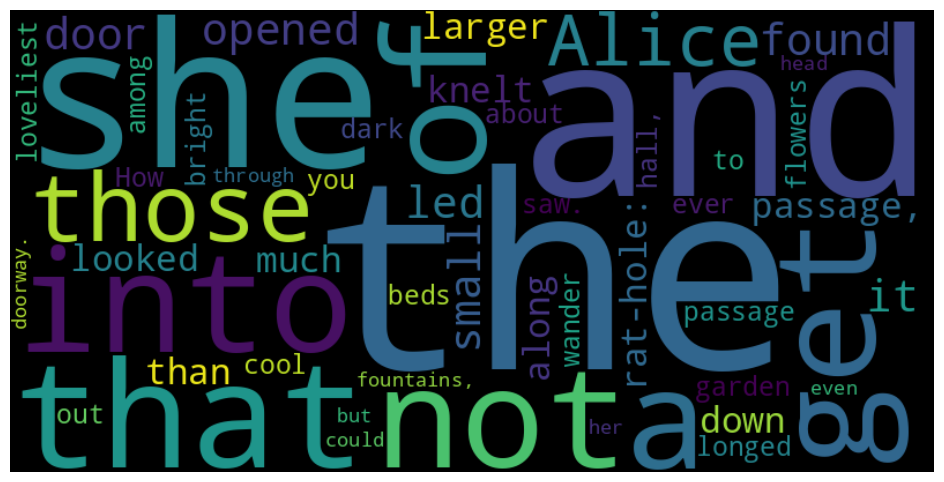

In [4]:
# Exemple de texte
document = """Alice opened the door and found that it led into a small passage,
not much larger than a rat-hole: she knelt down and looked along the passage
into the loveliest garden you ever saw. How she longed to get out of that dark hall,
and wander about among those beds of bright flowers and those cool fountains,
but she could not even get her head through the doorway."""

# Comptage des mots
words = document.split()                      # Découpage simple
word_counts = Counter(words)                  # Comptage des occurrences

# Word cloud
wc = WordCloud(width=800, height=400)         # Creation du word cloud
wc.generate_from_frequencies(word_counts)     # Generation

plt.figure(figsize=(12, 6))                   # Affichage
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

wc.to_file("wordcloud.png")                   # Sauvegarde de l'image

**Encodage des données**

Les textes peuvent présenter des problèmes d'encodage (Latin-1, UTF-8, etc.).  
Pour éviter ces difficultés, on convertit généralement tout le corpus vers un
format unique, le plus courant étant UTF-8.


In [157]:
# Exemple de chaine avec caracteres accentues
chaine = u"Klüft skräms inför på fédéral électoral große"

# Normalisation Unicode et suppression des accents
chaine = unicodedata.normalize('NFKD', chaine) \
                    .encode('ascii', 'ignore') \
                    .decode('utf-8')

print(chaine)

Kluft skrams infor pa federal electoral groe


**Suppression des tags XML/HTML**

Les données textuelles peuvent provenir de pages web ou contenir des entêtes et
autres balises. Une première étape consiste à extraire uniquement le texte.  
La librairie [BeautifulSoup](https://www.crummy.com/software/BeautifulSoup/bs4/doc/)  permet de supprimer facilement les tags et de
récupérer le contenu textuel.


In [158]:
# Exemple de page HTML
page = """
<!DOCTYPE html>
<html> <head> <title>Machine Learning - Apprentissage</title> </head>
  <body>
<h1>Le cours de Machine Learning est à la FDS </h1> (<a href=https://sciences.edu.umontpellier.fr>).
 Situé à Montpellier [où il fait toujours beau]
</body> </html>"""

print("Document original :", page, "\n")

# Suppression des tags HTML
def strip_html(text):
    soup = BeautifulSoup(text, "html.parser")  # Parsing du HTML
    return soup.get_text()                     # Extraction du texte

page = strip_html(page)
print("Document sans les tags :", page)

Document original : 
<!DOCTYPE html>
<html> <head> <title>Machine Learning - Apprentissage</title> </head>
  <body>
<h1>Le cours de Machine Learning est à la FDS </h1> (<a href=https://sciences.edu.umontpellier.fr>).
 Situé à Montpellier [où il fait toujours beau]
</body> </html> 

Document sans les tags : 

  Machine Learning - Apprentissage 

Le cours de Machine Learning est à la FDS  ().
 Situé à Montpellier [où il fait toujours beau]
 



**Utilisation d'expressions régulières**  

De nombreuses transformations peuvent être réalisées avec des expressions
régulières (librairie `re`). Par exemple, la fonction suivante permet de
supprimer le texte placé entre crochets [].  



In [159]:
# Supprime le texte entre crochets []
def remove_between_square_brackets(text):
    return re.sub(r'\[[^]]*\]', '', text)

page = remove_between_square_brackets(page)
print(page)



  Machine Learning - Apprentissage 

Le cours de Machine Learning est à la FDS  ().
 Situé à Montpellier 
 


Par exemple les expressions régulières peuvent être utilisées pour nettoyer des tweets.

In [160]:
tweet = '#ML is thus a good example :D ;) RT @theUser: see http://ml.example.com'
#traitement des émoticones
emoticons_str = r"""
    (?:
        [:=;] # Eyes
        [oO\-]? # Nose (optional)
        [D\)\]\(\]/\\OpP] # Mouth
    )"""

#Prise en compte des éléments qui doivent être regroupés
regex_str = [
    emoticons_str,
    r'<[^>]+>', # HTML tags
    r'(?:@[\w_]+)', # @-mentions
    r"(?:\#+[\w_]+[\w\'_\-]*[\w_]+)", # hash-tags
    r'http[s]?://(?:[a-z]|[0-9]|[$-_@.&amp;+]|[!*\(\),]|(?:%[0-9a-f][0-9a-f]))+', # URLs

    r'(?:(?:\d+,?)+(?:\.?\d+)?)', # nombres
    r"(?:[a-z][a-z'\-_]+[a-z])", # mots avec - et '
    r'(?:[\w_]+)', # autres mots
    r'(?:\S)' # le reste
]

tokens_re = re.compile(r'('+'|'.join(regex_str)+')', re.VERBOSE | re.IGNORECASE)
emoticon_re = re.compile(r'^'+emoticons_str+'$', re.VERBOSE | re.IGNORECASE)

def tokenize(s):
    return tokens_re.findall(s)

def preprocess(s, lowercase=False):
    tokens = tokenize(s)
    if lowercase:
        tokens = [
            tok if emoticon_re.search(tok) else tok.lower()
            for tok in tokens
        ]
    return tokens

# un example de tweet

print ("Un exemple de tweet : \n",tweet)

print ("\nLe tweet avec un processus normal de transformation\n")
print (word_tokenize(tweet))
print ("\nLe tweet avec des expressions régulières\n")
words=preprocess(tweet)
print(words)

Un exemple de tweet : 
 #ML is thus a good example :D ;) RT @theUser: see http://ml.example.com

Le tweet avec un processus normal de transformation

['#', 'ML', 'is', 'thus', 'a', 'good', 'example', ':', 'D', ';', ')', 'RT', '@', 'theUser', ':', 'see', 'http', ':', '//ml.example.com']

Le tweet avec des expressions régulières

['#ML', 'is', 'thus', 'a', 'good', 'example', ':D', ';)', 'RT', '@theUser', ':', 'see', 'http://ml.example.com']


**Gérer les contractions**

Les contractions peuvent être gênantes pour certains traitements, car elles
réduisent plusieurs mots en une seule forme (par exemple `don't` pour `do not`).
Pour garder un contrôle sur cette étape, on peut simplement définir un petit
dictionnaire de correspondance qui remplace quelques contractions fréquentes par
leur forme développée.

> **Remarque :** il existe des librairies comme `contraction` qui se chargent de réaliser ces transformations.

In [161]:
contractions_map = {
    "don't": "do not",
    "doesn't": "does not",
    "can't": "cannot",
    "won't": "will not",
    "i'm": "i am",
    "it's": "it is",
    "you're": "you are",
    "they're": "they are",
    "we're": "we are",
}

def expand_contractions(text):
    # Normalisation simple des apostrophes typographiques
    text = text.replace("’", "'")
    tokens = text.split()
    expanded = []
    for t in tokens:
        key = t.lower()
        if key in contractions_map:
            expanded.extend(contractions_map[key].split())
        else:
            expanded.append(t)
    return " ".join(expanded)

text = "I’m happy but I don't know why."
print(expand_contractions(text))


i am happy but I do not know why.


# Plus loin dans les pré-traitements des documents


Dans cette section, nous allons aller un peu plus loin dans le pré-traitement des
documents. L'objectif est de transformer le texte en une forme exploitable pour
un classifieur. Selon les données et la tâche visée, plusieurs opérations peuvent être utiles : extraction des tokens, normalisation des mots, lemmatisation, stemmatisation, détection d'entités nommées ou encore suppression de mots peu informatifs.

Le nettoyage peut aussi inclure d'autres opérations déjà vues (extraction du texte dans une page HTML, gestion de la ponctuation, etc.). Ces
choix dépendent bien entendu du corpus.

Dans la suite, nous utiliserons deux librairies courantes pour effectuer ces
pré-traitements : [la librairie NLTK (Natural Language Toolkit)](http://www.nltk.org) et [la librairie SpaCy](https://spacy.io/).


## Utilisation de NLTK

[NLTK](http://www.nltk.org) est une bibliothèque Python dédiée au traitement automatique des langues.
Elle propose des outils pour tokeniser, normaliser, lemmatiser ou analyser des
textes dans plusieurs langues y compris le français.


In [162]:
document = (
    "Alice opened the door and found that it led into a small passage, not "
    "much larger than a rat-hole: she knelt down and looked along the passage "
    "into the loveliest garden you ever saw. How she longed to get out of that "
    "dark hall, and wander about among those beds of bright flowers and those "
    "cool fountains, but she could not even get her head through the doorway"
)

Sous NLTK, le découpage d'un texte en phrases se fait avec la fonction
`sent_tokenize`. Une phrase est ici définie comme une unité de texte délimitée
par des signes de ponctuation tels que le point, le point d'interrogation ou le
point d'exclamation.

In [163]:
phrases = sent_tokenize(document)        # Decoupage en phrases

for i, phrase in enumerate(phrases):
    print(f"Phrase {i+1} :", phrase)

Phrase 1 : Alice opened the door and found that it led into a small passage, not much larger than a rat-hole: she knelt down and looked along the passage into the loveliest garden you ever saw.
Phrase 2 : How she longed to get out of that dark hall, and wander about among those beds of bright flowers and those cool fountains, but she could not even get her head through the doorway


**Découpage en tokens (*tokenisation*)**   

Un *token* correspond à une unité élémentaire du texte, souvent un mot ou un
symbole. En pratique, on travaille rarement directement avec les mots tels
qu'ils apparaissent dans le texte mais plutôt avec les tokens produits par la
"tokenisation".  

En Python, un texte est une chaîne de caractères. On peut donc utiliser des
méthodes simples, comme `lower` pour la mise en minuscules ou `split` pour
obtenir une première version des tokens.

> **Remarque :** on utilise une fonction pour plus de lisibilité (< 80 colonnes).

In [164]:
# Affiche les tokens sur plusieurs lignes (< 80 colonnes)
def afficher_tokens(tokens):
    print("Tokens :")
    line = ""
    for tok in tokens:
        t = f"'{tok}'"
        if len(line) + len(t) + 1 > 80:
            print(line)
            line = t
        else:
            line = t if line == "" else line + " " + t
    if line:
        print(line)
    print()
    print("Nombre de tokens :", len(tokens))

In [165]:
print("Conversion du document en minuscules")
print(document.lower())
print()

# Decoupage simple avec split
document_splitted = document.split()

# Affichage des tokens
afficher_tokens(document_splitted)

Conversion du document en minuscules
alice opened the door and found that it led into a small passage, not much larger than a rat-hole: she knelt down and looked along the passage into the loveliest garden you ever saw. how she longed to get out of that dark hall, and wander about among those beds of bright flowers and those cool fountains, but she could not even get her head through the doorway

Tokens :
'Alice' 'opened' 'the' 'door' 'and' 'found' 'that' 'it' 'led' 'into' 'a' 'small'
'passage,' 'not' 'much' 'larger' 'than' 'a' 'rat-hole:' 'she' 'knelt' 'down'
'and' 'looked' 'along' 'the' 'passage' 'into' 'the' 'loveliest' 'garden' 'you'
'ever' 'saw.' 'How' 'she' 'longed' 'to' 'get' 'out' 'of' 'that' 'dark' 'hall,'
'and' 'wander' 'about' 'among' 'those' 'beds' 'of' 'bright' 'flowers' 'and'
'those' 'cool' 'fountains,' 'but' 'she' 'could' 'not' 'even' 'get' 'her' 'head'
'through' 'the' 'doorway'

Nombre de tokens : 68



Avec NLTK, le découpage en tokens se fait avec la fonction `word_tokenize`. Ce
tokenizer est plus élaboré que la méthode `split` : il sépare la ponctuation,
gère certains cas particuliers et produit des unités mieux adaptées aux tâches
de traitement du langage.

> **Remarque :** dans les exemples, on voit que la ponctuation peut être intégrée au mot avec
`split`, alors qu'elle devient un token distinct avec NLTK. Nous verrons plus
loin que NLTK peut aussi analyser ces tokens grâce à l'étiquetage grammatical.


In [166]:
# Liste des tokens de la premiere phrase
tokens = word_tokenize(document)

# Affichage des tokens
afficher_tokens(tokens)

Tokens :
'Alice' 'opened' 'the' 'door' 'and' 'found' 'that' 'it' 'led' 'into' 'a' 'small'
'passage' ',' 'not' 'much' 'larger' 'than' 'a' 'rat-hole' ':' 'she' 'knelt'
'down' 'and' 'looked' 'along' 'the' 'passage' 'into' 'the' 'loveliest' 'garden'
'you' 'ever' 'saw' '.' 'How' 'she' 'longed' 'to' 'get' 'out' 'of' 'that' 'dark'
'hall' ',' 'and' 'wander' 'about' 'among' 'those' 'beds' 'of' 'bright' 'flowers'
'and' 'those' 'cool' 'fountains' ',' 'but' 'she' 'could' 'not' 'even' 'get'
'her' 'head' 'through' 'the' 'doorway'

Nombre de tokens : 73


**Étiquetage grammatical (*Part of Speech Tagging*)**

L'étiquetage grammatical consiste à associer à chaque token une catégorie
morpho-syntaxique (e.g. verbe, nom, préposition, etc.). Avec NLTK, cette opération se fait avec la fonction `pos_tag`, qui prend une liste de tokens et retourne les catégories correspondantes.


In [167]:
# Affiche les couples (token, tag) en colonnes
def afficher_pos(tokens_tag):
    print("Tokens et tags :")
    for tok, tag in tokens_tag:
        print(f"{tok:<20} {tag}")
    print()

for phrase_nltk in phrases:
    print("Phrase :", phrase_nltk)

    tokens = word_tokenize(phrase_nltk)
    tokens_tag = nltk.pos_tag(tokens)

    afficher_pos(tokens_tag)

Phrase : Alice opened the door and found that it led into a small passage, not much larger than a rat-hole: she knelt down and looked along the passage into the loveliest garden you ever saw.
Tokens et tags :
Alice                NNP
opened               VBD
the                  DT
door                 NN
and                  CC
found                VBD
that                 IN
it                   PRP
led                  VBD
into                 IN
a                    DT
small                JJ
passage              NN
,                    ,
not                  RB
much                 RB
larger               JJR
than                 IN
a                    DT
rat-hole             JJ
:                    :
she                  PRP
knelt                VBD
down                 RB
and                  CC
looked               VBD
along                IN
the                  DT
passage              NN
into                 IN
the                  DT
loveliest            JJS
garden         

In [168]:
for phrase_nltk in phrases:
    print("Phrase :", phrase_nltk)

    tokens = word_tokenize(phrase_nltk)
    tokens_tag = nltk.pos_tag(tokens)

    print("Tags :")
    print(tokens_tag)
    print()

Phrase : Alice opened the door and found that it led into a small passage, not much larger than a rat-hole: she knelt down and looked along the passage into the loveliest garden you ever saw.
Tags :
[('Alice', 'NNP'), ('opened', 'VBD'), ('the', 'DT'), ('door', 'NN'), ('and', 'CC'), ('found', 'VBD'), ('that', 'IN'), ('it', 'PRP'), ('led', 'VBD'), ('into', 'IN'), ('a', 'DT'), ('small', 'JJ'), ('passage', 'NN'), (',', ','), ('not', 'RB'), ('much', 'RB'), ('larger', 'JJR'), ('than', 'IN'), ('a', 'DT'), ('rat-hole', 'JJ'), (':', ':'), ('she', 'PRP'), ('knelt', 'VBD'), ('down', 'RB'), ('and', 'CC'), ('looked', 'VBD'), ('along', 'IN'), ('the', 'DT'), ('passage', 'NN'), ('into', 'IN'), ('the', 'DT'), ('loveliest', 'JJS'), ('garden', 'NN'), ('you', 'PRP'), ('ever', 'RB'), ('saw', 'VBD'), ('.', '.')]

Phrase : How she longed to get out of that dark hall, and wander about among those beds of bright flowers and those cool fountains, but she could not even get her head through the doorway
Tags :
[(

Il est possible de connaître la liste de tous les tags disponibles avec NLTK en
utilisant la fonction `nltk.help.upenn_tagset()`.

In [169]:
nltk.help.upenn_tagset()

$: dollar
    $ -$ --$ A$ C$ HK$ M$ NZ$ S$ U.S.$ US$
'': closing quotation mark
    ' ''
(: opening parenthesis
    ( [ {
): closing parenthesis
    ) ] }
,: comma
    ,
--: dash
    --
.: sentence terminator
    . ! ?
:: colon or ellipsis
    : ; ...
CC: conjunction, coordinating
    & 'n and both but either et for less minus neither nor or plus so
    therefore times v. versus vs. whether yet
CD: numeral, cardinal
    mid-1890 nine-thirty forty-two one-tenth ten million 0.5 one forty-
    seven 1987 twenty '79 zero two 78-degrees eighty-four IX '60s .025
    fifteen 271,124 dozen quintillion DM2,000 ...
DT: determiner
    all an another any both del each either every half la many much nary
    neither no some such that the them these this those
EX: existential there
    there
FW: foreign word
    gemeinschaft hund ich jeux habeas Haementeria Herr K'ang-si vous
    lutihaw alai je jour objets salutaris fille quibusdam pas trop Monte
    terram fiche oui corporis ...
IN: preposition or

À partir de cet étiquetage, il devient possible de sélectionner uniquement les
tokens appartenant à une catégorie grammaticale donnée. Par exemple, on peut
décider de ne garder que les adjectifs et les verbes pour des
tâches comme la détection d'opinion ou l'analyse de sentiment.

In [170]:
word_tokens = word_tokenize(document)
pos = nltk.pos_tag(word_tokens)

# On conserve ici seulement les adjectifs (JJ) et les verbes (VB, VBD, VBG)
selective_pos = ['JJ', 'VB', 'VBD', 'VBG']

selective_pos_words = []
for word, tag in pos:
    if tag in selective_pos:
        selective_pos_words.append((word, tag))

print(selective_pos_words)

[('opened', 'VBD'), ('found', 'VBD'), ('led', 'VBD'), ('small', 'JJ'), ('rat-hole', 'JJ'), ('knelt', 'VBD'), ('looked', 'VBD'), ('saw', 'VBD'), ('longed', 'VBD'), ('get', 'VB'), ('bright', 'JJ'), ('cool', 'JJ'), ('get', 'VB')]


**Mots vides (*stop words*)**  

Les mots vides sont des mots très fréquents qui n'apportent en général pas
d'information utile pour l'apprentissage. NLTK fournit une liste prédéfinie de
stop words pour plusieurs langues. Lors de la première utilisation, il est
nécessaire de télécharger cette liste avec :

```python
nltk.download("stopwords")
```

In [171]:
# Affiche une liste de mots sur plusieurs lignes (< 80 colonnes)
def afficher_mots(mots):
    print("Mots :")
    line = ""
    for m in mots:
        t = f"'{m}'"
        if len(line) + len(t) + 1 > 80:
            print(line)
            line = t
        else:
            line = t if line == "" else line + " " + t
    if line:
        print(line)
    print()
    print("Nombre de mots :", len(mots))

In [172]:
# Stop words anglais
the_stopwords = set(stopwords.words("english"))

afficher_mots(sorted(the_stopwords))

Mots :
'a' 'about' 'above' 'after' 'again' 'against' 'ain' 'all' 'am' 'an' 'and' 'any'
'are' 'aren' 'aren't' 'as' 'at' 'be' 'because' 'been' 'before' 'being' 'below'
'between' 'both' 'but' 'by' 'can' 'couldn' 'couldn't' 'd' 'did' 'didn' 'didn't'
'do' 'does' 'doesn' 'doesn't' 'doing' 'don' 'don't' 'down' 'during' 'each' 'few'
'for' 'from' 'further' 'had' 'hadn' 'hadn't' 'has' 'hasn' 'hasn't' 'have'
'haven' 'haven't' 'having' 'he' 'he'd' 'he'll' 'he's' 'her' 'here' 'hers'
'herself' 'him' 'himself' 'his' 'how' 'i' 'i'd' 'i'll' 'i'm' 'i've' 'if' 'in'
'into' 'is' 'isn' 'isn't' 'it' 'it'd' 'it'll' 'it's' 'its' 'itself' 'just' 'll'
'm' 'ma' 'me' 'mightn' 'mightn't' 'more' 'most' 'mustn' 'mustn't' 'my' 'myself'
'needn' 'needn't' 'no' 'nor' 'not' 'now' 'o' 'of' 'off' 'on' 'once' 'only' 'or'
'other' 'our' 'ours' 'ourselves' 'out' 'over' 'own' 're' 's' 'same' 'shan'
'shan't' 'she' 'she'd' 'she'll' 'she's' 'should' 'should've' 'shouldn'
'shouldn't' 'so' 'some' 'such' 't' 'than' 'that' 'that'll' 't

Pour changer de langue, il suffit de specifier la langue des stopwords à utiliser avec `set(stopwords.words(...))`.

> **Remarque :** `stopwords.fileids()` permet de connaître les langues disponibles.

In [173]:
print ("Liste des langues disponibles")
print (stopwords.fileids())

# Stop words francais
print ("\nList des stopwords pour le français")
the_stopwords_fr = set(stopwords.words("french"))

afficher_mots(sorted(the_stopwords_fr))

Liste des langues disponibles
['albanian', 'arabic', 'azerbaijani', 'basque', 'belarusian', 'bengali', 'catalan', 'chinese', 'danish', 'dutch', 'english', 'finnish', 'french', 'german', 'greek', 'hebrew', 'hinglish', 'hungarian', 'indonesian', 'italian', 'kazakh', 'nepali', 'norwegian', 'portuguese', 'romanian', 'russian', 'slovene', 'spanish', 'swedish', 'tajik', 'tamil', 'turkish']

List des stopwords pour le français
Mots :
'ai' 'aie' 'aient' 'aies' 'ait' 'as' 'au' 'aura' 'aurai' 'auraient' 'aurais'
'aurait' 'auras' 'aurez' 'auriez' 'aurions' 'aurons' 'auront' 'aux' 'avaient'
'avais' 'avait' 'avec' 'avez' 'aviez' 'avions' 'avons' 'ayant' 'ayante'
'ayantes' 'ayants' 'ayez' 'ayons' 'c' 'ce' 'ces' 'd' 'dans' 'de' 'des' 'du'
'elle' 'en' 'es' 'est' 'et' 'eu' 'eue' 'eues' 'eurent' 'eus' 'eusse' 'eussent'
'eusses' 'eussiez' 'eussions' 'eut' 'eux' 'eûmes' 'eût' 'eûtes' 'furent' 'fus'
'fusse' 'fussent' 'fusses' 'fussiez' 'fussions' 'fut' 'fûmes' 'fût' 'fûtes' 'il'
'ils' 'j' 'je' 'l' 'la' 'le

Il est aussi possible de retirer certains mots de la liste des stopwords si on
souhaite les conserver dans l'analyse.

In [174]:
# Mots que l'on souhaite retirer de la liste des stopwords
not_stopwords = {'haven', 'this', 'd', 'o'}

# Creation d'une nouvelle liste de stopwords sans ces mots
final_stop_words = {w for w in the_stopwords if w not in not_stopwords}

afficher_mots(sorted(final_stop_words))

Mots :
'a' 'about' 'above' 'after' 'again' 'against' 'ain' 'all' 'am' 'an' 'and' 'any'
'are' 'aren' 'aren't' 'as' 'at' 'be' 'because' 'been' 'before' 'being' 'below'
'between' 'both' 'but' 'by' 'can' 'couldn' 'couldn't' 'did' 'didn' 'didn't' 'do'
'does' 'doesn' 'doesn't' 'doing' 'don' 'don't' 'down' 'during' 'each' 'few'
'for' 'from' 'further' 'had' 'hadn' 'hadn't' 'has' 'hasn' 'hasn't' 'have'
'haven't' 'having' 'he' 'he'd' 'he'll' 'he's' 'her' 'here' 'hers' 'herself'
'him' 'himself' 'his' 'how' 'i' 'i'd' 'i'll' 'i'm' 'i've' 'if' 'in' 'into' 'is'
'isn' 'isn't' 'it' 'it'd' 'it'll' 'it's' 'its' 'itself' 'just' 'll' 'm' 'ma'
'me' 'mightn' 'mightn't' 'more' 'most' 'mustn' 'mustn't' 'my' 'myself' 'needn'
'needn't' 'no' 'nor' 'not' 'now' 'of' 'off' 'on' 'once' 'only' 'or' 'other'
'our' 'ours' 'ourselves' 'out' 'over' 'own' 're' 's' 'same' 'shan' 'shan't'
'she' 'she'd' 'she'll' 'she's' 'should' 'should've' 'shouldn' 'shouldn't' 'so'
'some' 'such' 't' 'than' 'that' 'that'll' 'the' 'their' 'the

Il est également possible d'étendre la liste des stop words.  

Cela peut être utile lorsque l'on travaille dans un domaine particulier. Par exemple, si l'on cherche à analyser l'opinion sur des films, des mots comme *cinéma* ou *film* sont très fréquents et ne sont pas toujours discriminants.


In [175]:
# Mots que l'on souhaite ajouter aux stop words pour un domaine specifique
new_stopwords = ['cinema', 'movie']

# Extension de la liste finale
final_stop_words = final_stop_words.union(new_stopwords)

afficher_mots(sorted(final_stop_words))

Mots :
'a' 'about' 'above' 'after' 'again' 'against' 'ain' 'all' 'am' 'an' 'and' 'any'
'are' 'aren' 'aren't' 'as' 'at' 'be' 'because' 'been' 'before' 'being' 'below'
'between' 'both' 'but' 'by' 'can' 'cinema' 'couldn' 'couldn't' 'did' 'didn'
'didn't' 'do' 'does' 'doesn' 'doesn't' 'doing' 'don' 'don't' 'down' 'during'
'each' 'few' 'for' 'from' 'further' 'had' 'hadn' 'hadn't' 'has' 'hasn' 'hasn't'
'have' 'haven't' 'having' 'he' 'he'd' 'he'll' 'he's' 'her' 'here' 'hers'
'herself' 'him' 'himself' 'his' 'how' 'i' 'i'd' 'i'll' 'i'm' 'i've' 'if' 'in'
'into' 'is' 'isn' 'isn't' 'it' 'it'd' 'it'll' 'it's' 'its' 'itself' 'just' 'll'
'm' 'ma' 'me' 'mightn' 'mightn't' 'more' 'most' 'movie' 'mustn' 'mustn't' 'my'
'myself' 'needn' 'needn't' 'no' 'nor' 'not' 'now' 'of' 'off' 'on' 'once' 'only'
'or' 'other' 'our' 'ours' 'ourselves' 'out' 'over' 'own' 're' 's' 'same' 'shan'
'shan't' 'she' 'she'd' 'she'll' 'she's' 'should' 'should've' 'shouldn'
'shouldn't' 'so' 'some' 'such' 't' 'than' 'that' 'that'll' '

Pour supprimer les mots vides d'un document, il suffit d'ignorer les tokens qui
figurent dans la liste des stopwords.

In [176]:
print("Avant suppression des stop words")
print(word_tokens)

tokens_no_stop = [w for w in word_tokens if w.lower() not in the_stopwords]

print("\nApres suppression des stop words")
print(tokens_no_stop)

Avant suppression des stop words
['Alice', 'opened', 'the', 'door', 'and', 'found', 'that', 'it', 'led', 'into', 'a', 'small', 'passage', ',', 'not', 'much', 'larger', 'than', 'a', 'rat-hole', ':', 'she', 'knelt', 'down', 'and', 'looked', 'along', 'the', 'passage', 'into', 'the', 'loveliest', 'garden', 'you', 'ever', 'saw', '.', 'How', 'she', 'longed', 'to', 'get', 'out', 'of', 'that', 'dark', 'hall', ',', 'and', 'wander', 'about', 'among', 'those', 'beds', 'of', 'bright', 'flowers', 'and', 'those', 'cool', 'fountains', ',', 'but', 'she', 'could', 'not', 'even', 'get', 'her', 'head', 'through', 'the', 'doorway']

Apres suppression des stop words
['Alice', 'opened', 'door', 'found', 'led', 'small', 'passage', ',', 'much', 'larger', 'rat-hole', ':', 'knelt', 'looked', 'along', 'passage', 'loveliest', 'garden', 'ever', 'saw', '.', 'longed', 'get', 'dark', 'hall', ',', 'wander', 'among', 'beds', 'bright', 'flowers', 'cool', 'fountains', ',', 'could', 'even', 'get', 'head', 'doorway']



**Racinisation (*stemming*) et lemmatisation**

NLTK propose deux approches pour ramener un mot à une forme plus simple :
la racinisation (*stemming*) et la lemmatisation.   

La racinisation utilise un algorithme comme celui de Porter pour ramener un mot à une racine approximative. Par exemple, *running*, *runner* et *runs* peuvent tous être ramenés à *run*.  
 La lemmatisation, elle, cherche une forme canonique plus proche de la langue.
Par exemple, *was* devient *be* et *mice* devient *mouse*.

Ces deux méthodes poursuivent le même objectif mais diffèrent dans leur
précision et leur mode de fonctionnement. Pour plus de détails, voir : [Racinisation — Wikipédia](https://fr.wikipedia.org/wiki/Racinisation) et [Lemmatisation Wikipedia](https://fr.wikipedia.org/wiki/Lemmatisation)


In [177]:
stemmer = nltk.stem.porter.PorterStemmer()#PorterStemmer()
lemmatizer = WordNetLemmatizer()

mots = ["running", "runner", "runs", "was", "mice", "better"]

print("Racinisation et lemmatisation :\n")
for m in mots:
    stem = stemmer.stem(m)
    lemma = lemmatizer.lemmatize(m)
    print("mot :", m, " | stem :", stem, " | lemma :", lemma)

Racinisation et lemmatisation :

mot : running  | stem : run  | lemma : running
mot : runner  | stem : runner  | lemma : runner
mot : runs  | stem : run  | lemma : run
mot : was  | stem : wa  | lemma : wa
mot : mice  | stem : mice  | lemma : mouse
mot : better  | stem : better  | lemma : better


La cellule suivante montre l'application sur les tokens du document d'Alice.

In [178]:
ps=nltk.stem.porter.PorterStemmer()
print ("tokens")
print (tokens)
print("\nStemming")
print([ps.stem(word) for word in tokens])

print("\nLemmatisation")
lem = nltk.stem.wordnet.WordNetLemmatizer()
print([lem.lemmatize(word) for word in tokens])

tokens
['How', 'she', 'longed', 'to', 'get', 'out', 'of', 'that', 'dark', 'hall', ',', 'and', 'wander', 'about', 'among', 'those', 'beds', 'of', 'bright', 'flowers', 'and', 'those', 'cool', 'fountains', ',', 'but', 'she', 'could', 'not', 'even', 'get', 'her', 'head', 'through', 'the', 'doorway']

Stemming
['how', 'she', 'long', 'to', 'get', 'out', 'of', 'that', 'dark', 'hall', ',', 'and', 'wander', 'about', 'among', 'those', 'bed', 'of', 'bright', 'flower', 'and', 'those', 'cool', 'fountain', ',', 'but', 'she', 'could', 'not', 'even', 'get', 'her', 'head', 'through', 'the', 'doorway']

Lemmatisation
['How', 'she', 'longed', 'to', 'get', 'out', 'of', 'that', 'dark', 'hall', ',', 'and', 'wander', 'about', 'among', 'those', 'bed', 'of', 'bright', 'flower', 'and', 'those', 'cool', 'fountain', ',', 'but', 'she', 'could', 'not', 'even', 'get', 'her', 'head', 'through', 'the', 'doorway']


NLTK propose aussi un stemmatiseur pour le français. En revanche, il ne fournit
pas de véritable lemmatiseur et il faut utiliser des outils comme `Spacy` que nous verrons juste après.


In [179]:
stemmer = SnowballStemmer("french")
phrase = "malade malades maladie maladies maladive"
tokens = word_tokenize(phrase)
print ("Avant transformation \n")
print (tokens)
stemmed = [stemmer.stem(word) for word in tokens]
print ("\n Après transformation\n")
print (stemmed)

Avant transformation 

['malade', 'malades', 'maladie', 'maladies', 'maladive']

 Après transformation

['malad', 'malad', 'malad', 'malad', 'malad']


## Utilisation de Spacy

[SpaCy](https://spacy.io/) est une bibliothèque avancée pour le traitement automatique du langage.  
Elle propose de nombreuses fonctionnalités : tokenisation, étiquetage grammatical, lemmatisation, reconnaissance deentités nommées, etc. Elle prend également en charge plusieurs langues, dont le français.  

Le traitement d'un texte dans SpaCy se fait à l'aide d'un objet `nlp` qui
applique un pipeline aux éléments du document et génère un objet `Doc`. Ce
pipeline comprend, selon le modèle utilisé, la tokenisation, l'étiquetage
grammatical, la lemmatisation et d'autres modules. Les modèles disponibles dépendent de la langue.  

<img src="http://www.lirmm.fr/~poncelet/PipelineSpacy.png" align="center">


Par défaut, SpaCy utilise l'anglais.  
Pour utiliser SpaCy en français, il est nécessaire d'installer d'abord le
modèle linguistique associé :


In [180]:
%%capture
!python -m spacy download fr_core_news_sm

La cellule illustre le fonctionnement du modèle français complet de SpaCy en
affichant, pour chaque token, sa catégorie grammaticale, son lemme et son rôle
syntaxique dans la phrase.

In [181]:
# Chargement du modele francais complet
nlp = spacy.load("fr_core_news_sm")

# Exemple de texte plus long
texte = ("Alice marche rapidement dans le jardin. "
         "Elle admire les belles fleurs et pense qu'il fera beau demain.")

# Creation du Doc
doc = nlp(texte)

# Affichage des informations principales pour chaque token
for token in doc:
    print("token :", token.text,
          "| pos :", token.pos_,
          "| lemma :", token.lemma_,
          "| dep :", token.dep_)

token : Alice | pos : NOUN | lemma : alice | dep : nsubj
token : marche | pos : VERB | lemma : marche | dep : ROOT
token : rapidement | pos : ADV | lemma : rapidement | dep : advmod
token : dans | pos : ADP | lemma : dans | dep : case
token : le | pos : DET | lemma : le | dep : det
token : jardin | pos : NOUN | lemma : jardin | dep : obl:mod
token : . | pos : PUNCT | lemma : . | dep : punct
token : Elle | pos : PRON | lemma : lui | dep : nsubj
token : admire | pos : VERB | lemma : admirer | dep : ROOT
token : les | pos : DET | lemma : le | dep : det
token : belles | pos : ADJ | lemma : bel | dep : amod
token : fleurs | pos : NOUN | lemma : fleur | dep : obj
token : et | pos : CCONJ | lemma : et | dep : cc
token : pense | pos : VERB | lemma : penser | dep : conj
token : qu' | pos : SCONJ | lemma : que | dep : mark
token : il | pos : PRON | lemma : il | dep : nsubj
token : fera | pos : VERB | lemma : faire | dep : ccomp
token : beau | pos : NOUN | lemma : beau | dep : obj
token : demain 

Nous revenons sur Alice en Anglais.

In [182]:
# remise des ressources en anglais pour la suite
nlp = spacy.load("en_core_web_sm")

document = (
    "Alice opened the door and found that it led into a small passage, not "
    "much larger than a rat-hole: she knelt down and looked along the passage "
    "into the loveliest garden you ever saw. How she longed to get out of that "
    "dark hall, and wander about among those beds of bright flowers and those "
    "cool fountains, but she could not even get her head through the doorway"
)

**Découpage en phrases, tokenisation et analyse grammaticale**

Le découpage en phrases se fait via l'attribut `sents` du `Doc`. Après le passage
du texte dans le pipeline, cet attribut permet d'accéder aux différentes phrases
détectées dans le document.


In [183]:
# Le document est en anglais
doc = nlp(document)

# Affichage des phrases detectees par Spacy
for phrase in doc.sents:
    print("phrase :", phrase)

# Sauvegarde des phrases dans une liste
sentences = [sent.text.strip() for sent in doc.sents]

phrase : Alice opened the door and found that it led into a small passage, not much larger than a rat-hole: she knelt down and looked along the passage into the loveliest garden you ever saw.
phrase : How she longed to get out of that dark hall, and wander about among those beds of bright flowers and those cool fountains, but she could not even get her head through the doorway



SpaCy permet d'obtenir de nombreuses informations sur les tokens : le token lui-même, son index (position en nombre de caractères), le lemme associé (voir plus loin), s'il s'agit d'un caractère de ponctuation ou d'un espace, sa forme (où un *X* représente une majuscule et un *x* une minuscule), sa catégorie grammaticale (*Part of Speech Tagging*), le tag associé, ou encore s'il correspond à une entité nommée, etc.

La liste complète des différents attributs disponibles pour un token est consultable [ici](https://spacy.io/api/token).

In [184]:
#traitement de la première phrase
first_sentence=nlp(sentences[0])

for token in first_sentence:
    # l'objet token contient différents attributs
    print("{0}\t{1}\t{2}\t{3}\t{4}\t{5}\t{6}\t{7}\t{8}".format(
        token.text,
        token.idx,
        token.lemma_,
        token.is_punct,
        token.is_space,
        token.shape_,
        token.pos_,
        token.tag_,
        token.ent_type_
    ))

Alice	0	Alice	False	False	Xxxxx	PROPN	NNP	PERSON
opened	6	open	False	False	xxxx	VERB	VBD	
the	13	the	False	False	xxx	DET	DT	
door	17	door	False	False	xxxx	NOUN	NN	
and	22	and	False	False	xxx	CCONJ	CC	
found	26	find	False	False	xxxx	VERB	VBD	
that	32	that	False	False	xxxx	SCONJ	IN	
it	37	it	False	False	xx	PRON	PRP	
led	40	lead	False	False	xxx	VERB	VBD	
into	44	into	False	False	xxxx	ADP	IN	
a	49	a	False	False	x	DET	DT	
small	51	small	False	False	xxxx	ADJ	JJ	
passage	57	passage	False	False	xxxx	NOUN	NN	
,	64	,	True	False	,	PUNCT	,	
not	66	not	False	False	xxx	PART	RB	
much	70	much	False	False	xxxx	ADV	RB	
larger	75	large	False	False	xxxx	ADJ	JJR	
than	82	than	False	False	xxxx	ADP	IN	
a	87	a	False	False	x	DET	DT	
rat	89	rat	False	False	xxx	NOUN	NN	
-	92	-	True	False	-	NOUN	NN	
hole	93	hole	False	False	xxxx	NOUN	NN	
:	97	:	True	False	:	PUNCT	:	
she	99	she	False	False	xxx	PRON	PRP	
knelt	103	kneel	False	False	xxxx	VERB	VBD	
down	109	down	False	False	xxxx	ADP	RP	
and	114	and	False	False	xxx	CC

Il est également possible de visualiser les résultats de l'analyse grammaticale
à l'aide des outils intégrés de SpaCy, comme le module `displacy`.



In [185]:
# Phrase tres courte pour un graphe lisible
short_sentence = nlp("Alice eats an apple in the garden.")

# Visualisation dans le notebook
displacy.render(short_sentence,
                style="dep",
                jupyter=True,
                options={"distance": 80})

# Export en SVG pour LaTeX
svg = displacy.render(short_sentence,
                      style="dep",
                      jupyter=False,
                      options={"distance": 80})

with open("dep_graph.svg", "w", encoding="utf-8") as f:
    f.write(svg)


**Entités nommées (*Named Entity Recognition*)**

SpaCy permet également d'identifier les entités nommées dans un texte, comme les
noms de personnes, d'organisations, de lieux, ainsi que des dates, des montants,
ou d'autres expressions spécifiques.


In [186]:
# Exemple avec  entites nommees
text = ("Apple plans to open a new office in Paris in 2025. "
        "Tim Cook met Emmanuel Macron during his last visit.")

doc = nlp(text)

# Affichage des entites nommees
for ent in doc.ents:
    print(ent.text, "-", ent.label_, "-", spacy.explain(ent.label_))


Apple - ORG - Companies, agencies, institutions, etc.
Paris - GPE - Countries, cities, states
2025 - DATE - Absolute or relative dates or periods
Tim Cook - PERSON - People, including fictional
Emmanuel Macron - PERSON - People, including fictional
